## XMAC02 - Atividade Avaliativa 2
### Nome:
### Nro Matric:

In [17]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import expon, norm

Nas questões de 1 a 4 você deve utilizar o dataset nba2k.csv.

In [4]:
df = pd.read_csv('nba2k.csv')
df.head()

,Unnamed: 0,full_name,rating,jersey,team,position,b_day,height,weight,salary,country,draft_year,draft_round,draft_peak,college,version
0,0,LeBron James,97,#23,Los Angeles Lakers,F,12/30/84,2.06,113.4,37436858,USA,2003,1,1,NaN,NBA2k20
1,1,Kawhi Leonard,97,#2,Los Angeles Clippers,F,06/29/91,2.01,102.1,32742000,USA,2011,1,15,San Diego State,NBA2k20
2,2,Giannis Antetokounmpo,96,#34,Milwaukee Bucks,F-G,12/06/94,2.11,109.8,25842697,Greece,2013,1,15,NaN,NBA2k20
3,3,Kevin Durant,96,#7,Brooklyn Nets,F,09/29/88,2.08,104.3,37199000,USA,2007,1,2,Texas,NBA2k20
4,4,James Harden,96,#13,Houston Rockets,G,08/26/89,1.96,99.8,38199000,USA,2009,1,3,Arizona State,NBA2k20


### Questão 1 [valor: 0,5 pt]
Obtenha a média, o desvio padrão e a mediana do peso (`weight`) dos pivôs (position = C) americanos da NBA, ou seja, dos jogadores que jogam na posição de pivô e que tenham country igual a USA.

In [5]:
media = df[df['position']=='C']['weight'].mean()
desvio = df[df['position']=='C']['weight'].std()
mediana = df[df['position']=='C']['weight'].median()

print(media)
print(desvio)
print(mediana)

110.90625
8.99274899985917
110.44999999999999


### Questão 2 [valor: 0,5 pt]
Gere um gráfico contendo três boxplots comparando o `rating` dos jogadores das posições G (armador), F (ala) e C (pivô).

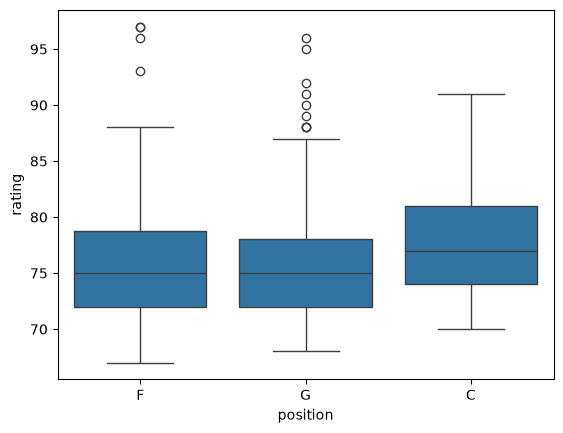

In [6]:
dfRating = df[(df['position'] == 'G') | (df['position'] == 'F') | (df['position'] == 'C')]
sns.boxplot(data= dfRating, x = 'position', y = 'rating')
plt.show()

### Questão 3 [valor: 1,0 pt]
Gere um gráfico que exiba o peso dos 10 jogadores mais bem pagos da NBA, organizados em ordem ascendente, ou seja, do mais leve para o mais pesado.

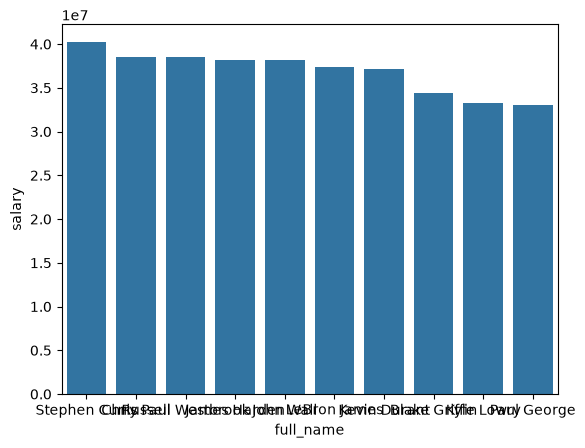

In [7]:
dfPagos = df.sort_values('salary', ascending= False).head(10)
sns.barplot(data= dfPagos, x = 'full_name', y='salary')
plt.show()

### Questão 4 [valor: 1,0 pt]
Gere dois gráficos de pizza lado a lado que exibam: \
A) o percentual de jogadores por rodada do draft (`draft_round`: 1, 2 e Undrafted); \
B) o valor total pago aos jogadores de cada rodada do draft.

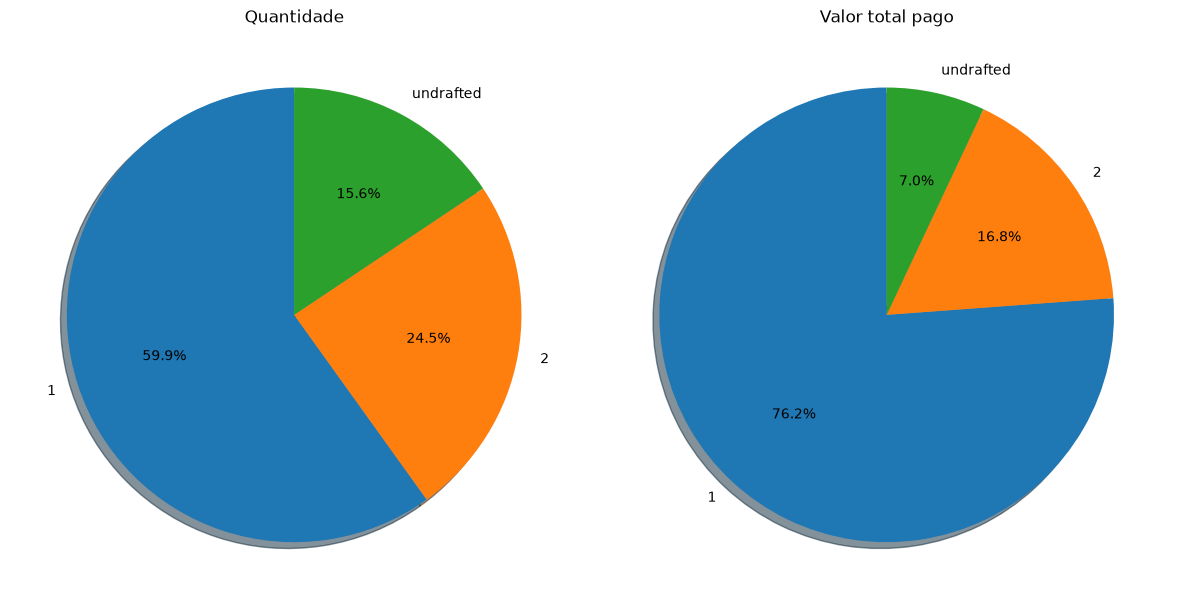

In [8]:
labels = ['1', '2', 'undrafted']

sizes1 = df.groupby('draft_round')['full_name'].count()

sizes2 = df.groupby('draft_round')['salary'].sum()

plt.rcParams['figure.figsize'] = [12, 6]
plt.subplot(1, 2, 1)
plt.pie(sizes1, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Quantidade')
plt.subplot(1, 2, 2)
plt.pie(sizes2, labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Valor total pago')
plt.tight_layout()
plt.show()

Nas questões de 5 a 8 deve-se usar os dataframes a seguir.

In [9]:
bike_day = pd.read_csv('day.csv')
students = pd.read_csv('student-por.csv', sep=';')

print('Bike — dados diários:', bike_day.shape)
print('Desempenho estudantil:', students.shape)

Bike — dados diários: (731, 16)
Desempenho estudantil: (649, 33)


### Questão 5 [valor: 0,75]

Utilize o DataFrame `bike_day`. Plote um gráfico de barras que mostre a média diária de locações de bike (`cnt`) por condição do tempo (`weathersit`). Substitua os códigos numéricos pelos nomes **Céu limpo** (1), **Nublado/Névoa** (2) e **Chuva/Neve leve** (3).

<Axes: xlabel='weathersit'>

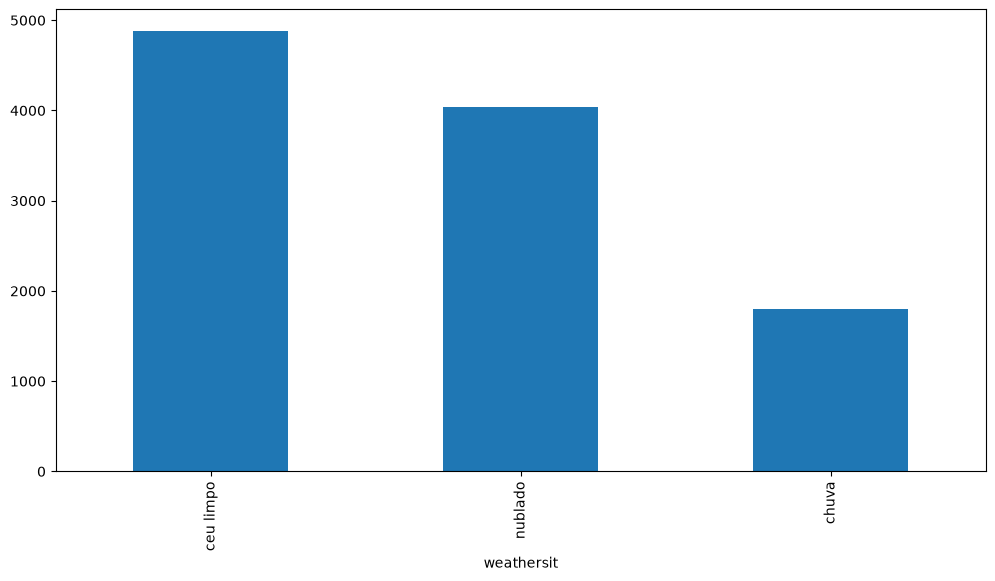

In [10]:
labels = {
    1: 'ceu limpo',
    2: 'nublado',
    3: 'chuva'
}

media = (
    bike_day.groupby('weathersit')['cnt']
    .mean()
    .rename(index = labels)
    )
media.plot(kind='bar')


### Questão 6 [valor: 0,75]

Utilize o DataFrame `students`.

1. Agrupe os estudantes pelo número de reprovações anteriores (`failures`).
2. Para cada categoria, obtenha:
   - a quantidade de estudantes;
   - a média da nota final (`G3`);
3. Armazene as duas medidas em um novo DataFrame com nomes de colunas claros.
4. Construa um **gráfico de linha** da média de `G3` em função do número de reprovações.

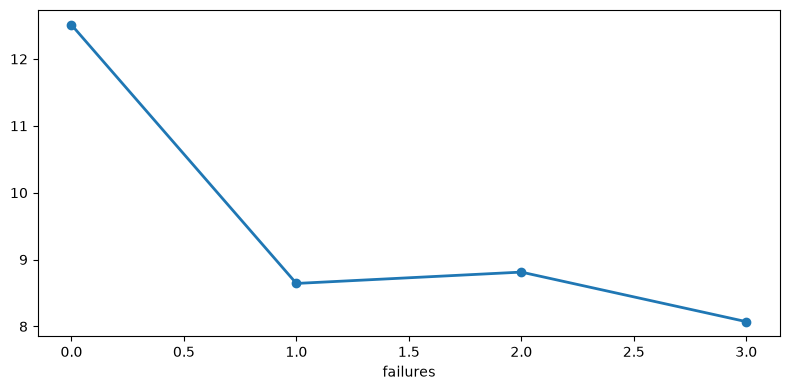

In [11]:
failures = (
    students.groupby('failures')
    .agg(
        quantidade = ('failures', 'count'),
        media = ('G3', 'mean')
    )
)

failures['media'].plot(kind='line', marker='o', linewidth=2, figsize=(8, 4))
plt.tight_layout()
plt.show()


### Questão 7 [valor: 0,5]

Utilize o DataFrame `students`. Construa um gráfico de barras agrupado pelo tipo de endereço (`address`: U = urbano, R = rural) que mostre a quantidade de alunos com e sem Internet em casa.

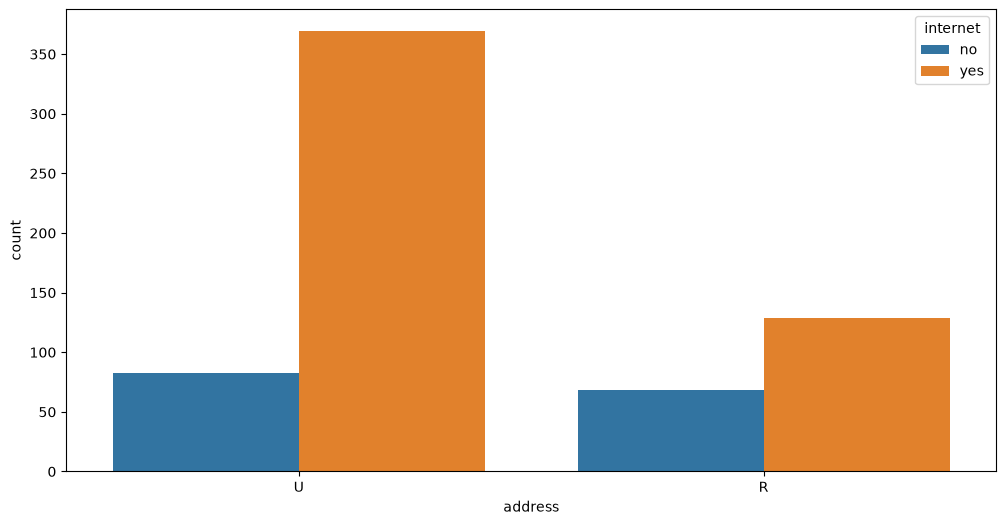

In [12]:
sns.countplot(data=students, x='address', hue= 'internet')
plt.show()

### Questão 8 [valor: 1,0]

Utilize o DataFrame `students`.

1. Investigue a relação entre a escolaridade da mãe (`Medu`: 0 = nenhuma ... 4 = ensino superior) e a intenção de cursar o ensino superior (`higher`).
2. Construa uma tabela de contingência **normalizada por linha**: cada linha deverá mostrar as proporções de respostas `yes` e `no` dentro daquela categoria de escolaridade da mãe.
3. Exiba os valores como percentuais, arredondados para uma casa decimal.
4. Construa um **gráfico de barras empilhadas**.
5. Escreva uma interpretação breve dos resultados.

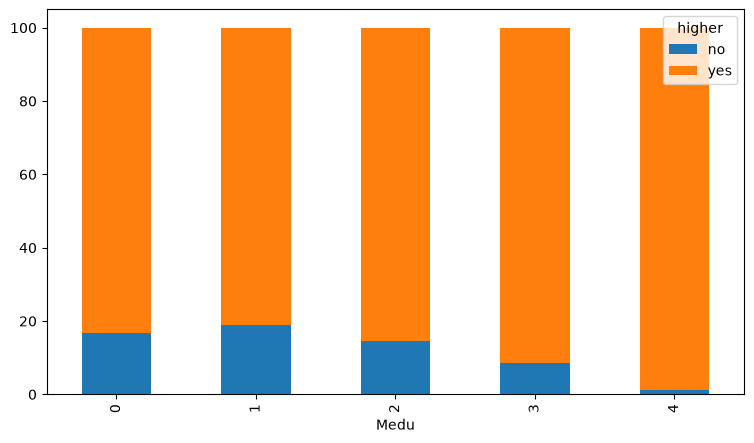

In [16]:
escolaridade_mae = pd.crosstab(
    index = students['Medu'],
    columns= students['higher'],
    normalize= 'index'
)

escolaridade_mae = escolaridade_mae * 100

escolaridade_mae.plot(
    kind='bar', stacked=True, figsize=(9, 5)
)

plt.show()



Nas questões 9 e 10 considere a Distribuição Normal (Aula 12).

### Questão 9 [valor: 1,0]
Pacotes de café são preenchidos com um peso médio de 500 g, com um desvio padrão de 8 g. Admitindo-se que os pesos estão normalmente distribuídos, determine: \
a) a porcentagem de pacotes com mais de 510 g; \
b) a porcentagem de pacotes com peso entre 490 g e 505 g; \
c) em um lote de 2.000 pacotes, quantos pacotes devem pesar menos de 485 g.

In [19]:
p1 = norm.sf(510, 500, 8)
print(f'{p1 * 100:.2f}%')

p2 = norm.cdf(505, 500, 8) - norm.cdf(490, 500, 8)
print(f'{p2 * 100:.2f}%')

p3 = norm.cdf(490, 500, 8)
print(f'{p3 * 100:.2f}%')



10.56%
62.84%
10.56%


### Questão 10 [valor: 1,0]
A vida útil de certo modelo de lâmpada é normalmente distribuída, com média de 1.200 horas e desvio padrão de 150 horas. \
a) O fabricante deseja estabelecer uma garantia de modo que apenas 2% das lâmpadas sejam substituídas antes da expiração da garantia. Qual deve ser o prazo (em horas)? Dica: use a função ppf \
b) Construa um gráfico da função densidade de probabilidade entre μ - 3σ e μ + 3σ, destacando a área correspondente às lâmpadas que falham antes do prazo de garantia.

Nas questões 11 e 12 considere a Distribuição Exponencial (Aula 13).

### Questão 11 [valor: 1,0]
Uma central de suporte recebe, em média, 9 chamados por hora. Considere que os chamados seguem um processo de Poisson homogêneo.

a) Qual é o tempo médio de espera, em minutos, entre dois chamados consecutivos?

b) Qual é a probabilidade de que o próximo chamado ocorra em menos de 4 minutos?

c) Qual é a probabilidade de que o tempo de espera ultrapasse 10 minutos?

d) Qual é a probabilidade de que o próximo chamado ocorra entre 5 e 10 minutos?

### Questão 12 [valor: 1,0]
Um servidor recebe, em média, 20 requisições por minuto, seguindo um processo de Poisson homogêneo. Trabalhe com o tempo em **segundos**.

a) Gere 10.000 tempos de espera entre requisições consecutivas.

b) Construa um histograma dos valores simulados.

c) Calcule a média e o desvio padrão dos tempos simulados e compare com os valores teóricos da distribuição.

d) Calcule a proporção de tempos de espera inferiores a 2 segundos e compare com a probabilidade teórica.

e) Determine o tempo t para o qual existe uma probabilidade de 90% de que a próxima requisição ocorra até esse instante e indique-o em um gráfico da função densidade de probabilidade.